# Titanic Survival Prediction

This notebook builds a machine learning pipeline to predict Titanic passenger survival.

The improved version focuses on professional ML workflow discipline:

- split before preprocessing
- no manual preprocessing before the split
- baseline model with `DummyClassifier`
- reusable `Pipeline` and `ColumnTransformer`
- cross-validation on the training set only
- final evaluation on the test set once
- saving the full preprocessing + model pipeline for FastAPI

## 1. Imports and Project Paths

In [1]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from app.ml_pipeline import TitanicFeatureEngineer

RANDOM_STATE = 42
DATA_PATH = PROJECT_ROOT / "data" / "Titanic-Dataset.csv"
MODEL_PATH = PROJECT_ROOT / "model" / "model.pkl"
NOTEBOOK_MODEL_PATH = PROJECT_ROOT / "notebook" / "model.pkl"

## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Basic Data Checks

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Cabin       687
Age         177
Embarked      2
dtype: int64

In [6]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


## 4. Target Distribution

The Titanic target is not perfectly balanced, so accuracy alone is not enough. We will also track precision, recall, F1, and ROC AUC.

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


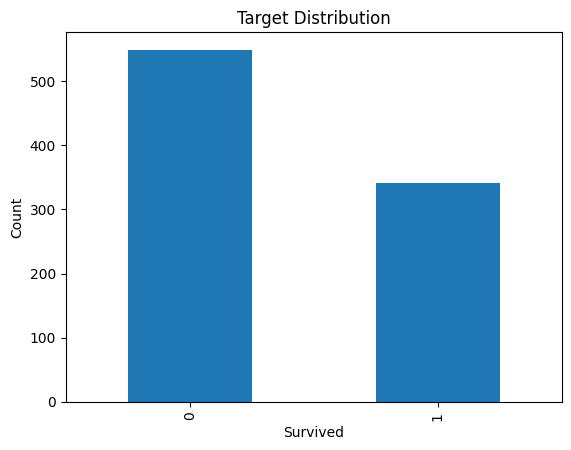

In [7]:
print(df["Survived"].value_counts())
print(df["Survived"].value_counts(normalize=True))

df["Survived"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

## 5. Simple EDA

These checks help understand the data before modeling. They are not used to fit preprocessing statistics.

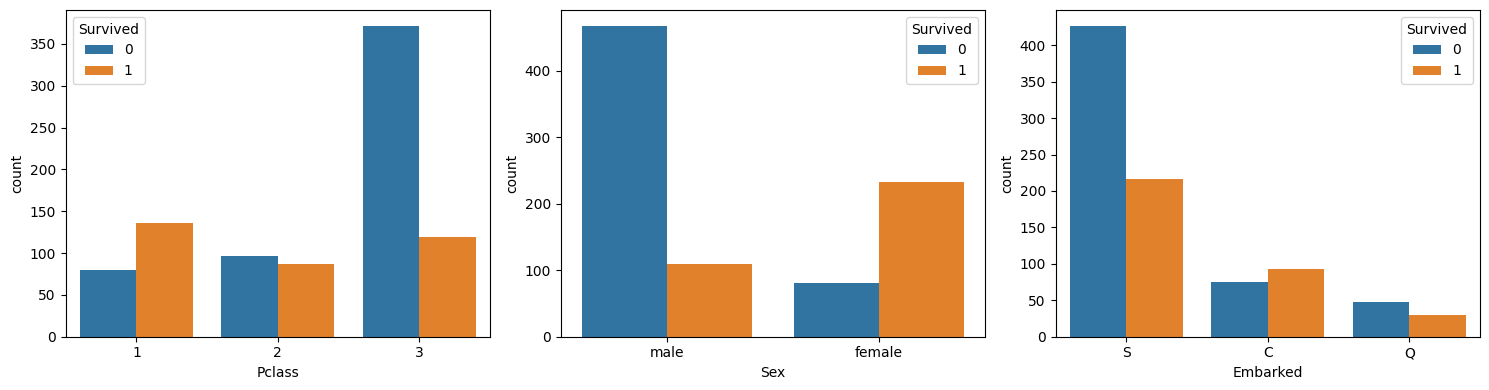

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[0])
sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[1])
sns.countplot(data=df, x="Embarked", hue="Survived", ax=axes[2])
plt.tight_layout()
plt.show()

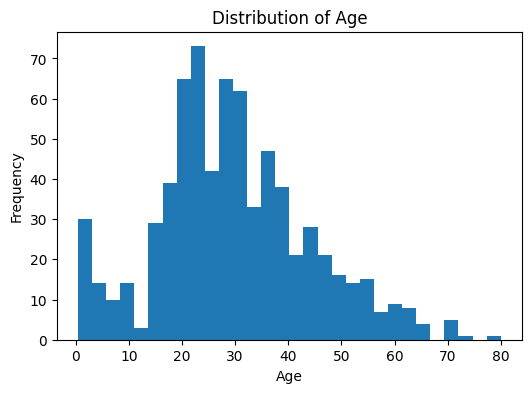

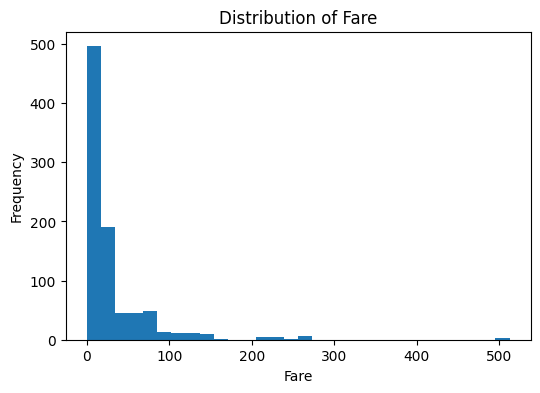

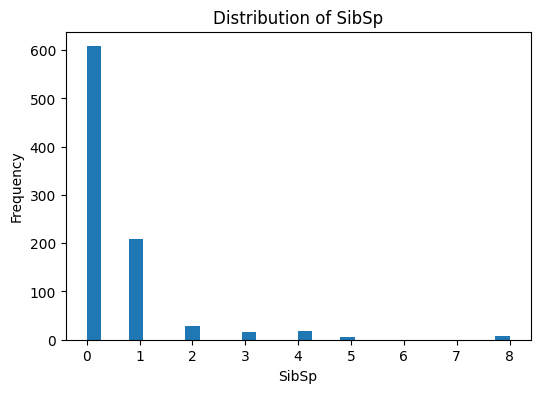

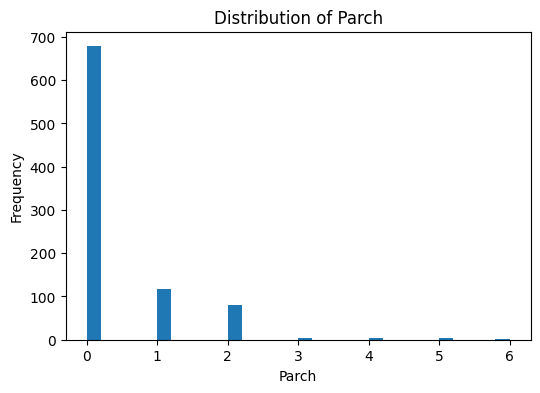

In [9]:
for col in ["Age", "Fare", "SibSp", "Parch"]:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 6. Train/Test Split

Important: the split happens before preprocessing and modeling. This helps avoid data leakage.

In [10]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target ratio:")
print(y_train.value_counts(normalize=True))
print()
print("Test target ratio:")
print(y_test.value_counts(normalize=True))

Train shape: (712, 11)
Test shape: (179, 11)
Train target ratio:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test target ratio:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## 7. Feature Engineering + Preprocessing Pipeline

`TitanicFeatureEngineer` creates features such as:

- `Title`
- `HasCabin`
- `FamilySize`
- `IsAlone`
- `LogFare`

Then `ColumnTransformer` handles numerical and categorical preprocessing.

In [11]:
numeric_features = ["Age", "HasCabin", "FamilySize", "IsAlone", "LogFare"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


def make_pipeline(model):
    return Pipeline(steps=[
        ("features", TitanicFeatureEngineer()),
        ("preprocessor", preprocessor),
        ("model", model),
    ])

## 8. Baseline Model

The baseline predicts the most frequent class. Any useful model should clearly beat this baseline.

In [12]:
baseline_model = make_pipeline(DummyClassifier(strategy="most_frequent"))
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred, zero_division=0))

Baseline Accuracy: 0.6145251396648045
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179



## 9. Model Comparison with Cross-Validation

Cross-validation is done on the training set only. The test set stays untouched until final evaluation.

In [13]:
models = {
    "Dummy Baseline": make_pipeline(DummyClassifier(strategy="most_frequent")),
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Random Forest": make_pipeline(RandomForestClassifier(
        n_estimators=80,
        max_depth=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

comparison_rows = []

for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
    )

    row = {"Model": name}
    for metric in scoring:
        row[f"CV {metric}"] = scores[f"test_{metric}"].mean()
        row[f"CV {metric} std"] = scores[f"test_{metric}"].std()

    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows).sort_values("CV roc_auc", ascending=False)
comparison.round(4)

,Model,CV accuracy,CV accuracy std,CV precision,CV precision std,CV recall,CV recall std,CV f1,CV f1 std,CV roc_auc,CV roc_auc std
1,Logistic Regression,0.8244,0.0140,0.7815,0.0384,0.7585,0.0341,0.7683,0.0132,0.8747,0.0201
2,Random Forest,0.8301,0.0166,0.8162,0.0400,0.7215,0.0357,0.7649,0.0237,0.8735,0.0244
0,Dummy Baseline,0.6166,0.0027,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000


## 10. Final Model Selection

Logistic Regression was selected because it achieved strong ROC AUC and recall while staying simple and explainable.

Random Forest had similar accuracy, but Logistic Regression is easier to explain for this portfolio project and performed slightly better on ROC AUC in cross-validation.

In [14]:
final_model = make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

## 11. Final Test Evaluation

In [15]:
print("Test Accuracy:", accuracy_score(y_test, final_pred))
print("Test Precision:", precision_score(y_test, final_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, final_pred))
print("Test F1:", f1_score(y_test, final_pred))
print("Test ROC AUC:", roc_auc_score(y_test, final_proba))
print()
print("Classification Report:")
print(classification_report(y_test, final_pred, zero_division=0))

Test Accuracy: 0.8268156424581006
Test Precision: 0.7878787878787878
Test Recall: 0.7536231884057971
Test F1: 0.7703703703703704
Test ROC AUC: 0.8653491436100132

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       110
           1       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



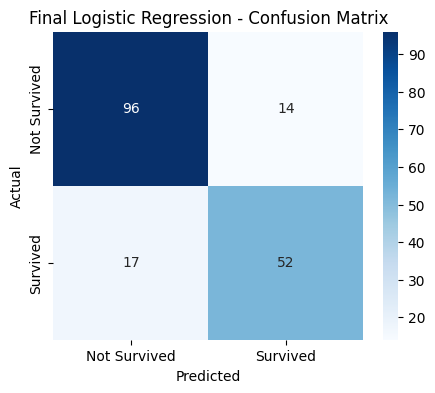

In [16]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"],
)
plt.title("Final Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 12. Error Analysis

Here we inspect a sample of wrong predictions to understand where the model struggles.

In [17]:
error_analysis = X_test.copy()
error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = final_pred
error_analysis["SurvivalProbability"] = final_proba
error_analysis["Correct"] = error_analysis["Actual"] == error_analysis["Predicted"]

error_analysis[~error_analysis["Correct"]].head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Actual,Predicted,SurvivalProbability,Correct
553,554,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C,1,0,0.116751,False
536,537,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.5500,B38,S,0,1,0.555195,False
712,713,1,"Taylor, Mr. Elmer Zebley",male,48.0,1,0,19996,52.0000,C126,S,1,0,0.310889,False
455,456,3,"Jalsevac, Mr. Ivan",male,29.0,0,0,349240,7.8958,NaN,C,1,0,0.099559,False
65,66,3,"Moubarek, Master. Gerios",male,NaN,1,1,2661,15.2458,NaN,C,1,0,0.435215,False
297,298,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,0,1,0.945742,False
40,41,3,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.0,1,0,7546,9.4750,NaN,S,0,1,0.568413,False
564,565,3,"Meanwell, Miss. (Marion Ogden)",female,NaN,0,0,SOTON/O.Q. 392087,8.0500,NaN,S,0,1,0.552321,False
502,503,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q,0,1,0.694289,False
17,18,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,1,0,0.170927,False


In [18]:
error_analysis.groupby(["Actual", "Predicted"])["PassengerId"].count().rename("count")

Actual  Predicted
0       0            96
        1            14
1       0            17
        1            52
Name: count, dtype: int64

## 13. Save Full Pipeline

The saved object is now the full pipeline: feature engineering + preprocessing + model.

This makes the FastAPI app simpler and safer because it no longer manually recreates preprocessing steps.

In [19]:
joblib.dump(final_model, MODEL_PATH)
joblib.dump(final_model, NOTEBOOK_MODEL_PATH)

print("Saved model to:", MODEL_PATH)
print("Saved notebook copy to:", NOTEBOOK_MODEL_PATH)

Saved model to: /mnt/data/titanic_work/Titanic/model/model.pkl
Saved notebook copy to: /mnt/data/titanic_work/Titanic/notebook/model.pkl


## 14. Conclusion

The improved notebook follows a cleaner machine learning workflow:

- No preprocessing before the train/test split
- Dummy baseline included
- Pipeline and ColumnTransformer used properly
- Cross-validation done on training data only
- Final test set used once for final evaluation
- Full pipeline saved for production use in FastAPI

Final model: **Logistic Regression Pipeline**

Final test results from this run:

- Accuracy: ~0.827
- Precision: ~0.788
- Recall: ~0.754
- F1-score: ~0.770
- ROC AUC: ~0.865